## Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd

np.random.seed(42)

## Criar uma estrutura 2D de tamanho n=100 em um linearspace

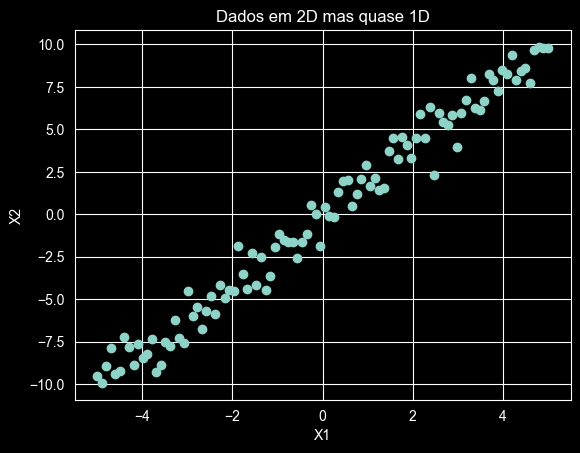

In [28]:
# Criar dados 2D que na verdade vivem em 1D (quase uma linha)
n = 100

#criar a equação
x = np.linspace(-5, 5, n)
y = 2 * x + np.random.normal(0, 1, n)  # linha + ruído


X = np.vstack([x, y]).T
# print(X)
plt.scatter(X[:, 0], X[:, 1])
plt.title("Dados em 2D mas quase 1D")
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [29]:
U, S, VT = svd(X, full_matrices=False)

print("Singular values:", S)

Singular values: [66.06356528  4.01050128]


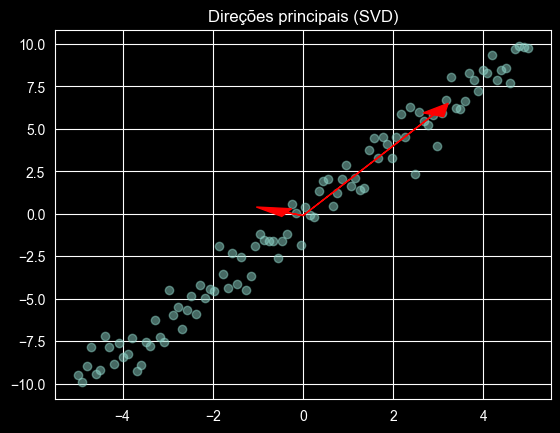

In [30]:
plt.scatter(X[:, 0], X[:, 1], alpha=0.5)

origin = np.mean(X, axis=0)

for i in range(2):
    direction = VT[i]
    scale = S[i] / 10
    plt.arrow(origin[0], origin[1],
              direction[0]*scale, direction[1]*scale,
              head_width=0.5, color='red')

plt.title("Direções principais (SVD)")
plt.show()

In [31]:
energy = S**2
energy_ratio = energy / energy.sum()

print("Energia relativa:", energy_ratio)

Energia relativa: [0.99632823 0.00367177]


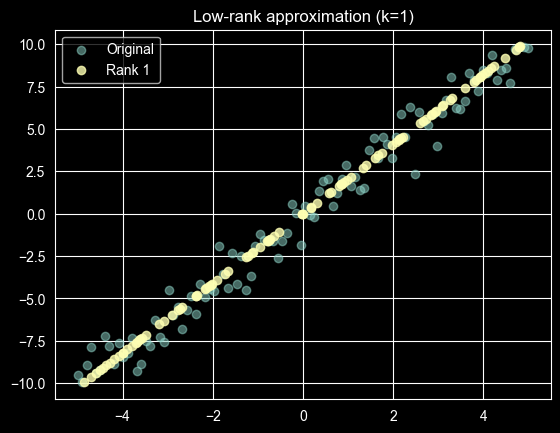

In [32]:
#escolher um k
k = 1

#refazer a matriz
X_approx = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

#print X normal
plt.scatter(X[:, 0], X[:, 1], label="Original", alpha=0.5)
#print X_approx
plt.scatter(X_approx[:, 0], X_approx[:, 1], label="Rank 1", alpha=0.8)
plt.legend()
plt.title("Low-rank approximation (k=1)")
plt.show()

In [33]:
error = np.linalg.norm(X - X_approx)
print("Erro da aproximação:", error)

Erro da aproximação: 4.010501277563108


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

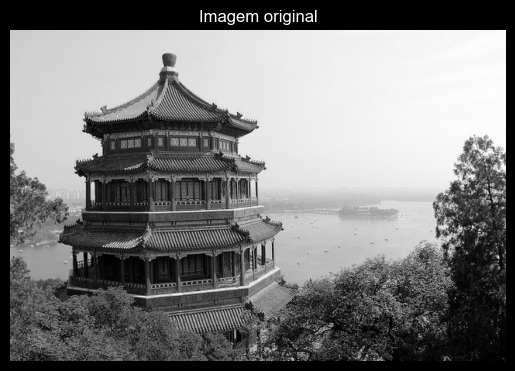

In [34]:
from sklearn.datasets import load_sample_image

china = load_sample_image("china.jpg")
gray = china.mean(axis=2)

plt.imshow(gray, cmap='gray')
plt.title("Imagem original")
plt.axis('off')

In [35]:
U, S, VT = svd(gray, full_matrices=False)
# print(S)

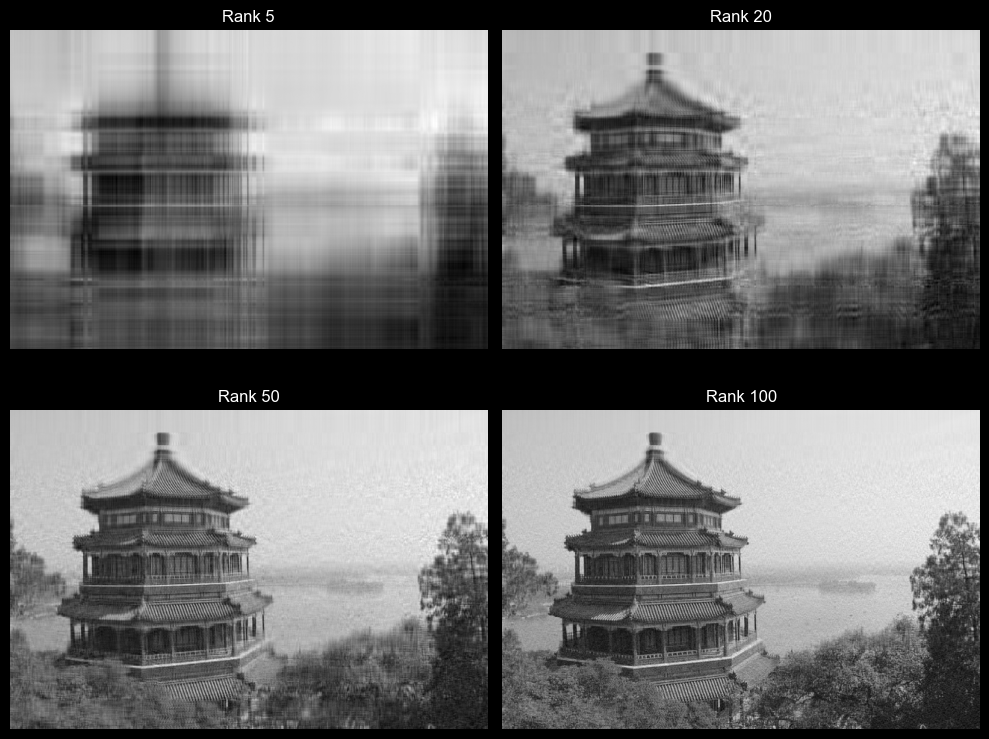

In [36]:
ranks = [5, 20, 50, 100]

plt.figure(figsize=(10, 8))

for i, k in enumerate(ranks):
    approx = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

    plt.subplot(2, 2, i+1)
    plt.imshow(approx, cmap='gray')
    plt.title(f"Rank {k}")
    plt.axis('off')

plt.tight_layout()
plt.show()

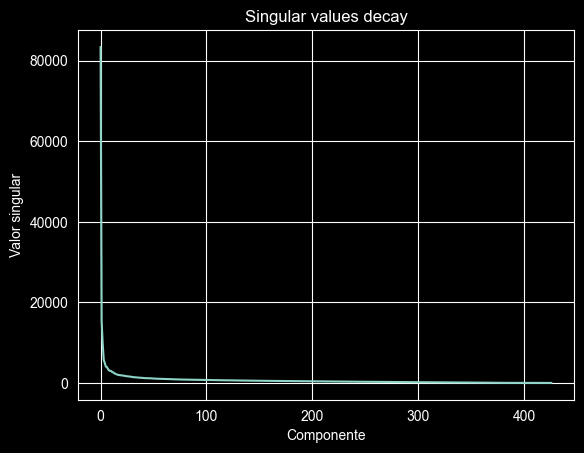

In [37]:
plt.plot(S)
plt.title("Singular values decay")
plt.xlabel("Componente")
plt.ylabel("Valor singular")
plt.show()

## Criar uma estrutura 15D de tamanho n=200

In [38]:
n_samples = 200
n_features = 15
true_rank = 3

# fatores latentes (200 x 3)
Z = np.random.randn(n_samples, true_rank)

# matriz de mistura (3 x 15)
W = np.random.randn(true_rank, n_features)

# dados gerados (200 x 15)
X = Z @ W

# adicionar ruído pequeno
noise = 0.1 * np.random.randn(n_samples, n_features)
X = X + noise

print("Shape dos dados:", X.shape)

Shape dos dados: (200, 15)


In [39]:
U, S, VT = svd(X, full_matrices=False)

print("Singular values:")
print(S)

Singular values:
[64.04478972 52.37149105 39.89601476  1.69333007  1.61984703  1.54681177
  1.51557761  1.50059762  1.39692598  1.35949792  1.3180614   1.28209654
  1.22922698  1.18425216  1.09074114]


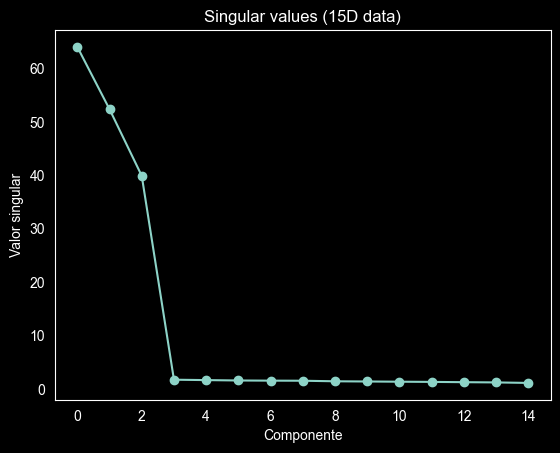

In [40]:
plt.plot(S, marker='o')
plt.title("Singular values (15D data)")
plt.xlabel("Componente")
plt.ylabel("Valor singular")
plt.grid()
plt.show()

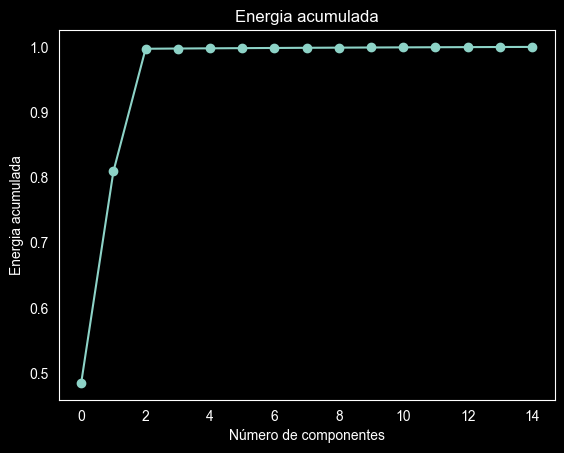

In [41]:
energy = S**2
energy_ratio = energy / energy.sum()

plt.plot(np.cumsum(energy_ratio), marker='o')
plt.title("Energia acumulada")
plt.xlabel("Número de componentes")
plt.ylabel("Energia acumulada")
plt.grid()
plt.show()

In [42]:
k = 3

X_approx = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]

error = np.linalg.norm(X - X_approx)
print("Erro com rank 3:", error)

Erro com rank 3: 4.869961912463513


In [43]:
errors = []

ks = range(1, 11)

for k in ks:
    X_approx = U[:, :k] @ np.diag(S[:k]) @ VT[:k, :]
    error = np.linalg.norm(X - X_approx)
    errors.append(error)
    print(f"k = {k:2d} | erro = {error:.4f}")

k =  1 | erro = 66.0165
k =  2 | erro = 40.1921
k =  3 | erro = 4.8700
k =  4 | erro = 4.5661
k =  5 | erro = 4.2691
k =  6 | erro = 3.9790
k =  7 | erro = 3.6791
k =  8 | erro = 3.3591
k =  9 | erro = 3.0549
k = 10 | erro = 2.7357
